# 03 - Tổng hợp bảng biểu phục vụ báo cáo
Notebook này gom các bảng và chỉ số cuối cùng từ dữ liệu đã làm sạch để chèn trực tiếp vào báo cáo Word.

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

_ = (plt, sns)

In [2]:
os.makedirs("outputs/report", exist_ok=True)

df = pd.read_csv("data/cleaned_reviews.csv")
summary = pd.read_csv("outputs/eda_summary.csv")

display(df.head())
display(summary)

,review_id,shop_id,item_id,product_url,product_name,brand,price,final_price,rating_count_total,user_id,...,reply_content,reply_created_at,reply_user_id,reply_is_admin,reply_like_count,source,comment_clean,reply_content_clean,review_len,has_reply
0,Anh KhoiPD DX_201234,FPTShop,59564510814,https://fptshop.com.vn/may-tinh-xach-tay/color...,Colorful Rimbook L1 i5 13420H (A10205500050),Colorful,14990000,14990000,3,Anh KhoiPD DX,...,NaN,NaN,NaN,NaN,NaN,FPTShop,máy dùng tốt,NaN,12,False
1,Bình Nguyễn_196901,FPTShop,108185810205,https://fptshop.com.vn/may-tinh-xach-tay/asus-...,Asus Zenbook 14 UX3405CA-ST629W Ultra 7-255H,Asus,34090000,34090000,2,Bình Nguyễn,...,"Chào anh Bình Dạ, sản phẩm không có màn hình c...",2026-03-28 01:17:57+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop,cho mình hỏi phiên bản này không cảm ứng phải ...,chào anh bình dạ sản phẩm không có màn hình cả...,55,True
2,Bình_210331,FPTShop,320017710671,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Air 15 M5 2026 10CPU/10GPU/24GB/1TB,Apple,45990000,45990000,89,Bình,...,"Chào anh Bình Dạ, cục sạc đi kèm là 35W ạ. Hiệ...",2026-04-20 14:25:41+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop,cho mình hỏi cái này cục sạc 35w hay 70w vậy,chào anh bình dạ cục sạc đi kèm là 35w ạ hiện ...,44,True
3,Thanh_205235,FPTShop,431825326108,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Pro 14 M5 Pro 2026 15CPU/16GPU/24GB/1TB,Apple,59990000,59990000,5,Thanh,...,"Chào anh Thanh, Dạ mẫu này là mẫu M5 Pro thườn...",2026-04-12 08:07:58+00:00,Đông Chí Linh,True,0.0,FPTShop,cái này lõi 15 16 là m5 thường chứ không phải ...,chào anh thanh dạ mẫu này là mẫu m5 pro thường...,60,True
4,Hishin_214039,FPTShop,741367556191,https://fptshop.com.vn/may-tinh-xach-tay/macbo...,MacBook Neo 13 8GB/256GB,Apple,16490000,16490000,27,Hishin,...,NaN,NaN,NaN,NaN,NaN,FPTShop,máy có hỗ trợ kết nối với máy in brother t236 ...,NaN,51,False


,metric,value
0,count_reviews,9108.000
1,min_rating,1.000
2,max_rating,5.000
3,avg_rating,4.737
4,median_rating,5.000
5,avg_review_len,78.790
6,min_review_len,2.000
7,max_review_len,837.000


In [3]:
if "has_reply" not in df.columns:
    if "reply_content" in df.columns:
        df["has_reply"] = df["reply_content"].fillna("").astype(str).str.strip().str.len() > 0
    else:
        df["has_reply"] = False

group_cols = ["shop_id", "item_id"]
for optional_col in ["product_name", "brand"]:
    if optional_col in df.columns:
        group_cols.append(optional_col)

table_by_item = df.groupby(group_cols).agg(
    review_count=("review_id", "count"),
    avg_rating=("rating_star", "mean"),
    avg_review_len=("review_len", "mean"),
    reply_count=("has_reply", "sum")
).reset_index()

table_by_item["avg_rating"] = table_by_item["avg_rating"].round(3)
table_by_item["avg_review_len"] = table_by_item["avg_review_len"].round(2)
table_by_item["reply_rate"] = (table_by_item["reply_count"] / table_by_item["review_count"]).round(4)

display(table_by_item.sort_values("review_count", ascending=False).head(20))
table_by_item.to_csv("outputs/report/table_by_item.csv", index=False, encoding="utf-8-sig")

,shop_id,item_id,product_name,brand,review_count,avg_rating,avg_review_len,reply_count,reply_rate
299,FPTShop,431997138342,Asus Vivobook E1404FA-NK186W R5 7520U,Asus,183,5.000,127.81,86,0.4699
367,FPTShop,528007133007,Macbook Air 13 M4 2025 10CPU/8GPU/16GB/256GB,Apple,152,4.714,57.84,145,0.9539
386,FPTShop,543667801489,Asus TUF Gaming FX507ZC4-HN095W i5 12500H,Asus,152,5.000,125.21,38,0.2500
10,FPTShop,560716967,Macbook Air 13 M2 2024 8CPU/8GPU/16GB/256GB,Apple,149,4.588,55.45,132,0.8859
436,FPTShop,604379534097,Lenovo Gaming LOQ E 15IAX9E i5 12450HX (83LK00...,Lenovo,143,4.429,57.13,138,0.9650
136,FPTShop,170116638221,ASUS Vivobook 15 X1504ZA-NJ517W i5-1235U,Asus,115,4.867,133.70,56,0.4870
541,FPTShop,760277157906,Asus Vivobook Flip TN3402YA-LZ188W R5 7530U,Asus,115,5.000,117.73,59,0.5130
181,FPTShop,223706537163,Asus Vivobook 14 OLED A1405ZA-KM264W i5 12500H,Asus,115,4.793,121.90,58,0.5043
261,FPTShop,359513625041,Asus Vivobook X1504VA-NJ526W i5 1335U,Asus,100,5.000,115.31,46,0.4600
31,FPTShop,28677142627,Asus Vivobook 15 OLED A1505VA-L1113W i5 13500H,Asus,92,5.000,123.96,38,0.4130


In [4]:
table_positive_negative = pd.DataFrame({
    "nhom": ["Tích cực (4-5 sao)", "Tiêu cực (1-2 sao)", "Trung tính (3 sao)"],
    "so_luong": [
        int((df["rating_star"] >= 4).sum()),
        int((df["rating_star"] <= 2).sum()),
        int((df["rating_star"] == 3).sum())
    ]
})

display(table_positive_negative)
table_positive_negative.to_csv("outputs/report/table_sentiment_groups.csv", index=False, encoding="utf-8-sig")

,nhom,so_luong
0,Tích cực (4-5 sao),3601
1,Tiêu cực (1-2 sao),96
2,Trung tính (3 sao),83


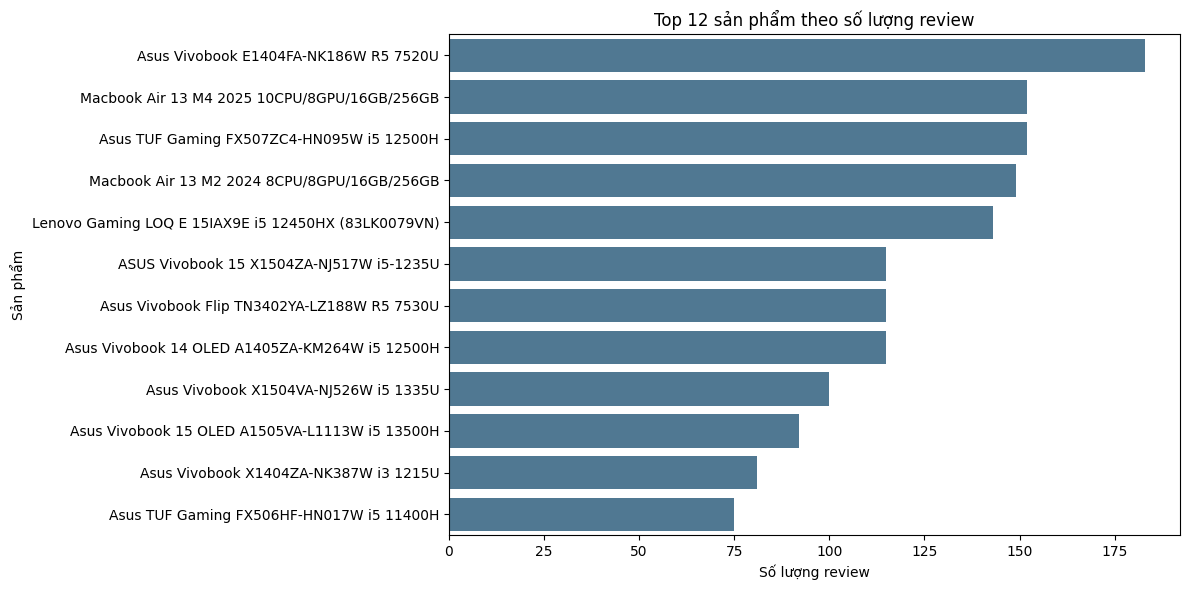

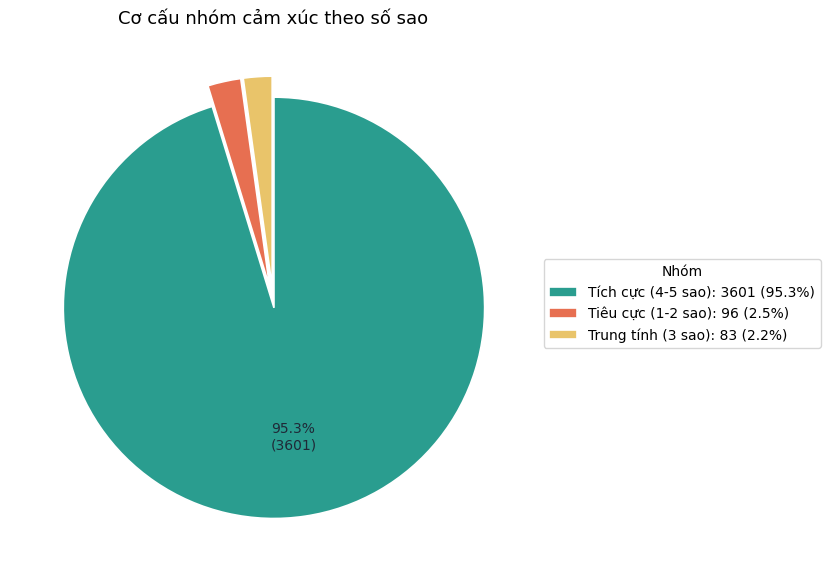

In [5]:
# Biểu đồ báo cáo: Top sản phẩm theo số lượng review và cơ cấu sentiment
top_items_plot = table_by_item.sort_values("review_count", ascending=False).head(12).copy()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_items_plot, x="review_count", y="product_name", color="#457b9d")
plt.title("Top 12 sản phẩm theo số lượng review")
plt.xlabel("Số lượng review")
plt.ylabel("Sản phẩm")
plt.tight_layout()
plt.savefig("outputs/report/chart_top_items_by_review_count.png", dpi=150)
plt.show()

# Biểu đồ tròn: ưu tiên dễ đọc, hạn chế chồng chữ ở lát cắt nhỏ
sentiment_counts = table_positive_negative["so_luong"]
sentiment_labels = table_positive_negative["nhom"]
total_reviews = int(sentiment_counts.sum())

def pct_with_count(pct):
    if pct < 4:
        return ""
    count = int(round(pct / 100 * total_reviews))
    return f"{pct:.1f}%\n({count})"

legend_labels = [
    f"{label}: {count} ({count / total_reviews:.1%})"
    for label, count in zip(sentiment_labels, sentiment_counts)
]

plt.figure(figsize=(8, 7))
wedges, _, autotexts = plt.pie(
    sentiment_counts,
    labels=None,
    autopct=pct_with_count,
    pctdistance=0.62,
    startangle=90,
    counterclock=False,
    explode=[0.02, 0.08, 0.08],
    colors=["#2A9D8F", "#E76F51", "#E9C46A"],
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
for text in autotexts:
    text.set_color("#1f2937")
    text.set_fontsize(10)

plt.title("Cơ cấu nhóm cảm xúc theo số sao", fontsize=13, pad=12)
plt.legend(wedges, legend_labels, title="Nhóm", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("outputs/report/chart_sentiment_groups_pie.png", dpi=150)
plt.show()

In [6]:
table_data_dictionary = pd.DataFrame([
    ["review_id", "Mã review duy nhất"],
    ["shop_id", "Nguồn bán hoặc mã shop (FPTShop)"],
    ["item_id", "Mã content dùng để gọi API comment của FPTShop"],
    ["product_name", "Tên sản phẩm"],
    ["brand", "Hãng sản phẩm"],
    ["price", "Giá niêm yết hoặc giá tham chiếu"],
    ["final_price", "Giá bán cuối cùng (nếu có)"],
    ["rating_count_total", "Tổng số lượt đánh giá của sản phẩm"],
    ["user_id", "Mã hoặc định danh người dùng đánh giá"],
    ["rating_star", "Số sao đánh giá (1-5)"],
    ["review_title", "Tiêu đề review (nếu có)"],
    ["comment", "Nội dung review gốc"],
    ["comment_clean", "Nội dung review sau làm sạch"],
    ["verified_purchase", "Cờ xác nhận đã mua hàng (nếu có)"],
    ["image_product", "Ảnh đại diện sản phẩm"],
    ["image_review", "Ảnh đính kèm đánh giá (nếu có)"],
    ["created_at", "Thời gian tạo review"],
    ["like_count", "Số lượt hữu ích"],
    ["product_items", "Biến thể/thuộc tính sản phẩm trong review (nếu có)"],
    ["reply_content", "Nội dung phản hồi từ shop/quản trị (nếu có)"],
    ["reply_created_at", "Thời gian phản hồi"],
    ["reply_user_id", "Định danh người phản hồi"],
    ["reply_is_admin", "Cờ phản hồi từ quản trị viên"],
    ["reply_like_count", "Số lượt hữu ích của phản hồi"],
    ["has_reply", "Cờ review có phản hồi từ shop/quản trị"],
    ["review_len", "Độ dài ký tự của review"],
    ["source", "Nguồn dữ liệu (FPTShop)"],
], columns=["ten_cot", "y_nghia"])

display(table_data_dictionary)
table_data_dictionary.to_csv("outputs/report/table_data_dictionary.csv", index=False, encoding="utf-8-sig")

,ten_cot,y_nghia
0,review_id,Mã review duy nhất
1,shop_id,Nguồn bán hoặc mã shop (FPTShop)
2,item_id,Mã content dùng để gọi API comment của FPTShop
3,product_name,Tên sản phẩm
4,brand,Hãng sản phẩm
5,price,Giá niêm yết hoặc giá tham chiếu
6,final_price,Giá bán cuối cùng (nếu có)
7,rating_count_total,Tổng số lượt đánh giá của sản phẩm
8,user_id,Mã hoặc định danh người dùng đánh giá
9,rating_star,Số sao đánh giá (1-5)


In [7]:
print("Đã tạo các bảng trong thư mục outputs/report")

Đã tạo các bảng trong thư mục outputs/report
